### I want to plot the distribution of colors across segments

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from IPython.display import display, HTML 
import matplotlib.colors as mcolors
import math
from collections import Counter
import matplotlib.cm as cm
import seaborn as sns

In [2]:
# Path to the directory containing the CSV files
english_directory_path = '/Users/rsudhir/Documents/GitHub/Data-Science-Project---Colors-Of-Romance/English-Analysis/English-Movie-CSVs'
hindi_directory_path = '/Users/rsudhir/Documents/GitHub/Data-Science-Project---Colors-Of-Romance/Hindi-Analysis/Hindi-Movie-CSVs'
korean_directory_path = '/Users/rsudhir/Documents/GitHub/Data-Science-Project---Colors-Of-Romance/Korean-Analysis/Korean-Movie-CSVs'

# List to hold each DataFrame
english_dfs = []
hindi_dfs = []
korean_dfs = []

# Loop through the files in the directory and load each CSV
for i in range(1, 26):
    english_file_path = os.path.join(english_directory_path, f'{i}.csv')
    hindi_file_path = os.path.join(hindi_directory_path, f'{i}.csv')
    korean_file_path = os.path.join(korean_directory_path, f'{i}.csv')

    df1 = pd.read_csv(english_file_path)
    df2 = pd.read_csv(hindi_file_path)
    df3 = pd.read_csv(korean_file_path)

    # Drop columns with NaN values
    df1 = df1.drop(columns=['color_10_r', 'color_10_g', 'color_10_b'])
    df2 = df2.drop(columns=['color_10_r', 'color_10_g', 'color_10_b'])
    df3 = df3.drop(columns=['color_10_r', 'color_10_g', 'color_10_b'])
    
    # Add a column to indicate which movie the data is from
    df1['movie_id'] = i
    df2['movie_id'] = i
    df3['movie_id'] = i
    
    english_dfs.append(df1)
    hindi_dfs.append(df2)
    korean_dfs.append(df3)

# Combine all DataFrames into a single DataFrame
english_combined_df = pd.concat(english_dfs, ignore_index=True)
hindi_combined_df = pd.concat(hindi_dfs, ignore_index=True)
korean_combined_df = pd.concat(korean_dfs, ignore_index=True)


# Display the combined DataFrame to ensure it looks correct
display(english_combined_df.head())
display(hindi_combined_df.head())
display(korean_combined_df.head())

,frame_path,color_1_r,color_1_g,color_1_b,color_2_r,color_2_g,color_2_b,color_3_r,color_3_g,color_3_b,...,color_7_r,color_7_g,color_7_b,color_8_r,color_8_g,color_8_b,color_9_r,color_9_g,color_9_b,movie_id
0,output_0000001.png,94,76,59,210,190,185,28,24,21,...,58,26,24,169,174,174,163,160,165,1
1,output_0000002.png,38,36,28,191,177,178,129,114,101,...,164,132,118,156,148,156,100,88,100,1
2,output_0000003.png,126,109,90,28,24,19,196,180,163,...,170,168,165,178,180,163,71,63,34,1
3,output_0000004.png,41,32,30,94,81,72,105,100,90,...,155,156,154,83,89,101,152,148,156,1
4,output_0000005.png,32,27,26,196,174,161,121,93,80,...,119,130,150,148,148,140,73,77,96,1


,frame_path,color_1_r,color_1_g,color_1_b,color_2_r,color_2_g,color_2_b,color_3_r,color_3_g,color_3_b,...,color_7_r,color_7_g,color_7_b,color_8_r,color_8_g,color_8_b,color_9_r,color_9_g,color_9_b,movie_id
0,output_0000001.png,117,55,10,232,219,96,231,90,12,...,136,91,33,180,162,100,180,173,96,1
1,output_0000002.png,4,4,4,8,4,4,8,4,4,...,8,4,4,8,4,4,8,4,4,1
2,output_0000003.png,199,163,104,17,17,8,170,130,77,...,27,69,69,108,140,132,100,148,134,1
3,output_0000004.png,168,147,89,106,90,47,9,9,6,...,187,5,47,89,122,140,44,61,73,1
4,output_0000005.png,37,49,32,186,199,163,135,139,109,...,88,106,100,130,162,156,192,26,50,1


,frame_path,color_1_r,color_1_g,color_1_b,color_2_r,color_2_g,color_2_b,color_3_r,color_3_g,color_3_b,...,color_7_r,color_7_g,color_7_b,color_8_r,color_8_g,color_8_b,color_9_r,color_9_g,color_9_b,movie_id
0,output_0000001.png,53,53,38,169,195,201,112,123,116,...,130,139,148,76,100,94,116,132,84,1
1,output_0000002.png,106,119,107,150,153,145,38,41,34,...,57,66,41,44,60,55,156,172,156,1
2,output_0000003.png,187,210,188,77,76,71,31,35,36,...,120,139,132,108,92,75,60,84,76,1
3,output_0000004.png,214,228,250,245,245,249,184,202,250,...,186,212,251,188,183,236,215,211,211,1
4,output_0000005.png,117,111,98,17,18,16,172,165,166,...,145,139,148,83,82,85,156,108,94,1


In [3]:
# Define the number of segments
num_segments = 5

# Loop through each movie and create a segment ID
for df in [english_combined_df, hindi_combined_df, korean_combined_df]:
    df['segment_id'] = df.groupby('movie_id').cumcount() // (df.groupby('movie_id')['frame_path'].transform('count') // num_segments)

In [4]:
def kmeans_for_segments(combined_df, num_clusters_per_segment=15):
    segment_clusters = []

    # Group by movie and segment
    grouped = combined_df.groupby(['movie_id', 'segment_id'])

    for (movie_id, segment_id), group in grouped:
        colors = []
        for i in range(1, 10):
            colors.append(group[[f'color_{i}_r', f'color_{i}_g', f'color_{i}_b']].dropna().values)
        
        colors_array = np.vstack(colors)

        if len(colors_array) >= num_clusters_per_segment:
            kmeans = KMeans(n_clusters=num_clusters_per_segment, n_init='auto', random_state=42)
            kmeans.fit(colors_array)
            segment_clusters.append((movie_id, segment_id, kmeans.cluster_centers_))
        else:
            print(f"Skipping segment {segment_id} of movie {movie_id} due to insufficient data points.")
    
    return segment_clusters

# Apply K-Means clustering to each language dataset
english_segment_clusters = kmeans_for_segments(english_combined_df)
hindi_segment_clusters = kmeans_for_segments(hindi_combined_df)
korean_segment_clusters = kmeans_for_segments(korean_combined_df)

Skipping segment 5 of movie 6 due to insufficient data points.
Skipping segment 5 of movie 7 due to insufficient data points.
Skipping segment 5 of movie 8 due to insufficient data points.
Skipping segment 5 of movie 19 due to insufficient data points.
Skipping segment 5 of movie 1 due to insufficient data points.
Skipping segment 5 of movie 3 due to insufficient data points.
Skipping segment 5 of movie 5 due to insufficient data points.
Skipping segment 5 of movie 9 due to insufficient data points.
Skipping segment 5 of movie 12 due to insufficient data points.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (11) found smaller than n_clusters (15). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Skipping segment 5 of movie 1 due to insufficient data points.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (11) found smaller than n_clusters (15). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (11) found smaller than n_clusters (15). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1152: ConvergenceWarning: Number of distinct clusters (11) found smaller than n_clusters (15). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Skipping segment 5 of movie 21 due to insufficient data points.
Skipping segment 5 of movie 22 due to insufficient data points.


In [5]:
def combine_segments(segment_clusters, num_segments=5):
    combined_segments = {}

    for segment_id in range(num_segments):
        segment_colors = []
        for movie_id, sid, centers in segment_clusters:
            if segment_id == sid:
                segment_colors.append(centers)
        
        combined_segments[segment_id] = np.vstack(segment_colors)
    
    return combined_segments

# Combine segments across movies for each language
english_combined_segments = combine_segments(english_segment_clusters)
hindi_combined_segments = combine_segments(hindi_segment_clusters)
korean_combined_segments = combine_segments(korean_segment_clusters)

In [6]:
def kmeans_on_combined_segments(combined_segments, num_clusters_per_combined_segment=30):
    final_segment_clusters = {}

    for segment_id, colors in combined_segments.items():
        if len(colors) >= num_clusters_per_combined_segment:
            kmeans = KMeans(n_clusters=num_clusters_per_combined_segment, n_init='auto', random_state=42)
            kmeans.fit(colors)
            final_segment_clusters[segment_id] = kmeans.cluster_centers_
        else:
            print(f"Skipping combined segment {segment_id} due to insufficient data points.")
    
    return final_segment_clusters

# Apply K-Means on combined segments for each language
english_final_segment_clusters = kmeans_on_combined_segments(english_combined_segments)
hindi_final_segment_clusters = kmeans_on_combined_segments(hindi_combined_segments)
korean_final_segment_clusters = kmeans_on_combined_segments(korean_combined_segments)


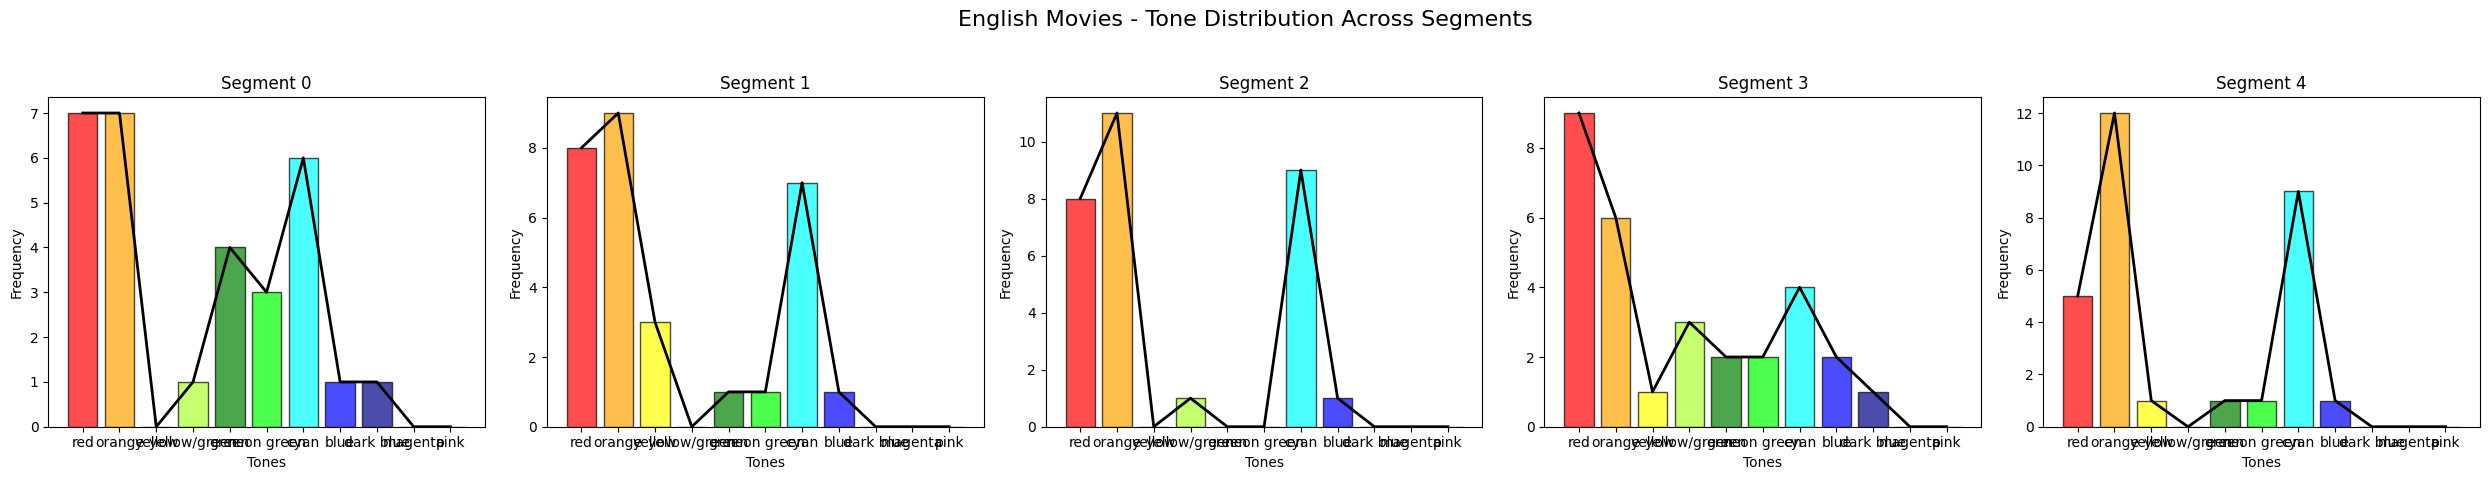

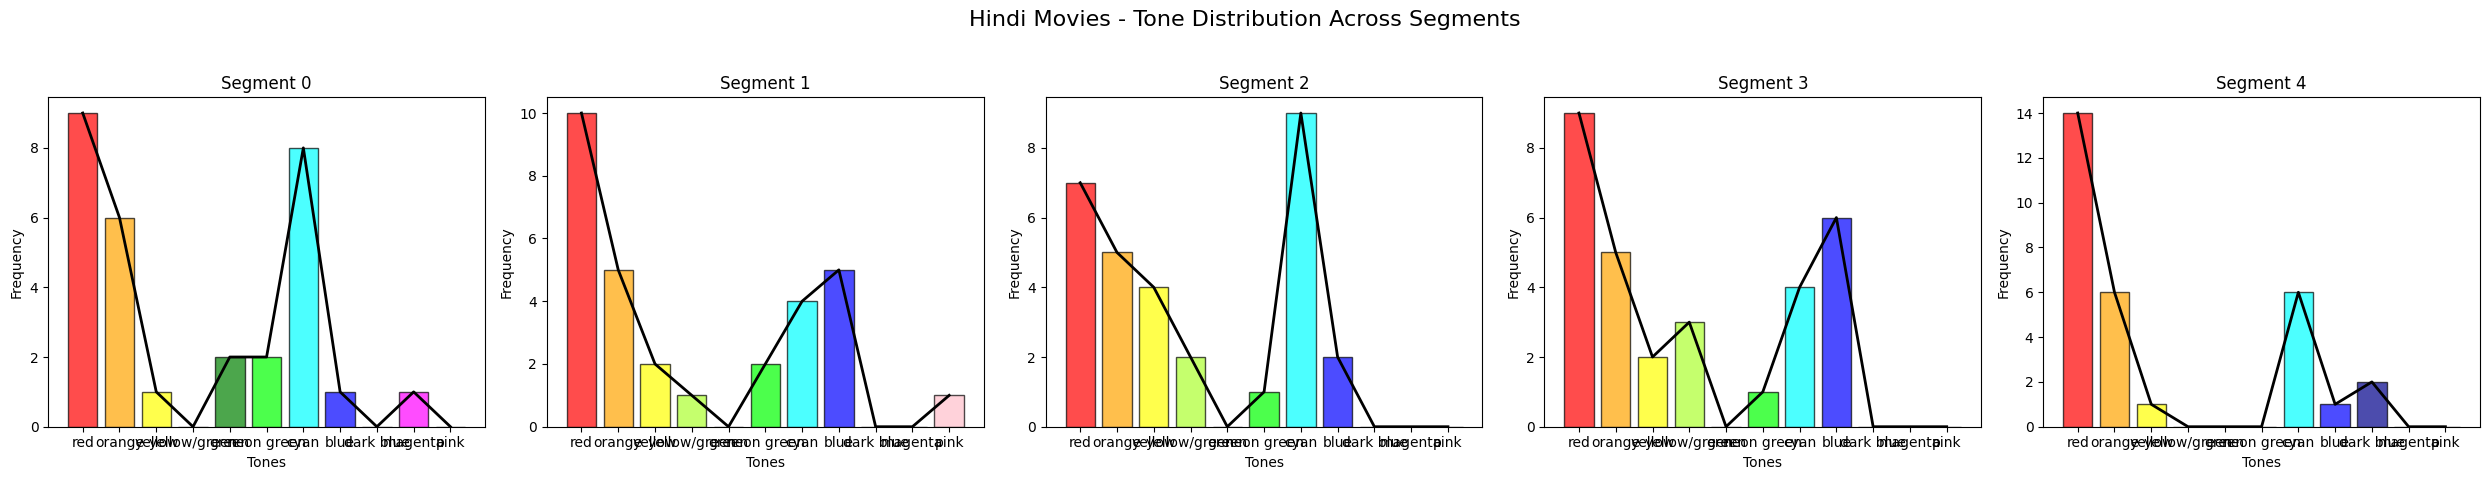

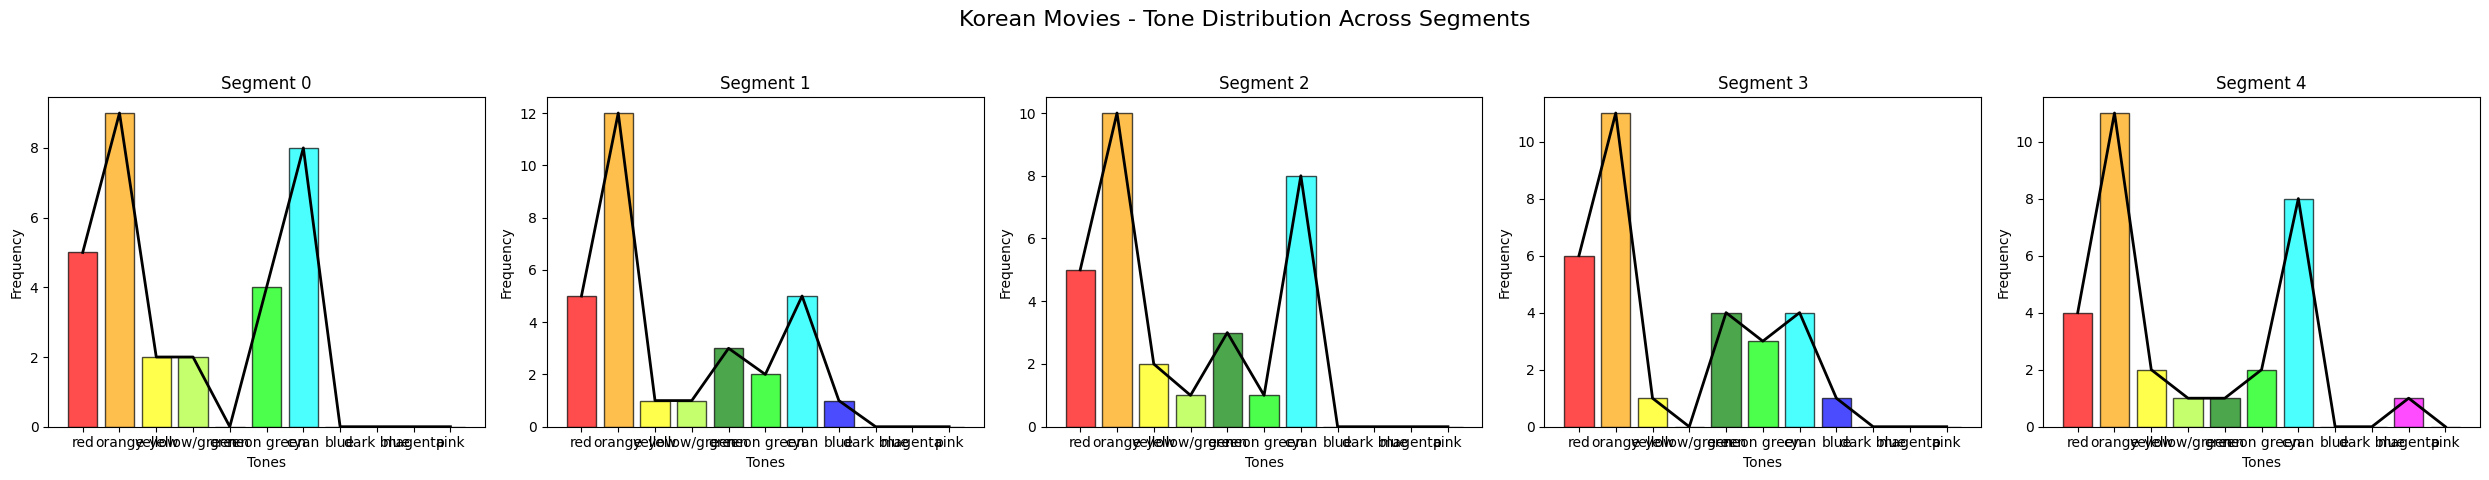

In [7]:
# Function to classify colors by tone
def classify_color_by_tone(hsv):
    hue = hsv[0] * 360  # Convert hue from [0, 1] to [0, 360]
    
    if hue < 30 or hue >= 330:
        return 'red'
    elif 30 <= hue < 60:
        return 'orange'
    elif 60 <= hue < 90:
        return 'yellow'
    elif 90 <= hue < 120:
        return 'yellow/green'
    elif 120 <= hue < 150:
        return 'green'
    elif 150 <= hue < 180:
        return 'neon green'
    elif 180 <= hue < 210:
        return 'cyan'
    elif 210 <= hue < 240:
        return 'blue'
    elif 240 <= hue < 270:
        return 'dark blue'
    elif 270 <= hue < 300:
        return 'magenta'
    elif 300 <= hue < 330:
        return 'pink'
    else:
        return 'unknown'
import matplotlib.pyplot as plt

# Function to classify tones and plot subplots for each segment
def classify_and_plot_per_segment(final_segment_clusters, language_title):
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))  # Create a 1x5 grid of subplots
    fig.suptitle(f'{language_title} - Tone Distribution Across Segments', fontsize=16)

    sorted_tones = ['red', 'orange', 'yellow', 'yellow/green', 'green', 
                    'neon green', 'cyan', 'blue', 'dark blue', 
                    'magenta', 'pink']
    
    tone_colors = {
        'red': '#FF0000',
        'orange': '#FFA500',
        'yellow': '#FFFF00',
        'yellow/green': '#ADFF2F',
        'green': '#008000',
        'neon green': '#00FF00',
        'cyan': '#00FFFF',
        'blue': '#0000FF',
        'dark blue': '#00008B',
        'magenta': '#FF00FF',
        'pink': '#FFC0CB'
    }
    
    for segment_id, centers in final_segment_clusters.items():
        color_tones = [classify_color_by_tone(mcolors.rgb_to_hsv([r/255, g/255, b/255])) for r, g, b in centers]
        tone_counts = Counter(color_tones)
        
        sorted_counts = [tone_counts[tone] if tone in tone_counts else 0 for tone in sorted_tones]

        axes[segment_id].bar(sorted_tones, sorted_counts, color=[tone_colors[tone] for tone in sorted_tones], alpha=0.7, edgecolor='black')
        axes[segment_id].plot(range(len(sorted_tones)), sorted_counts, 'k-', linewidth=2)
        axes[segment_id].set_title(f'Segment {segment_id}')
        axes[segment_id].set_xlabel('Tones')
        axes[segment_id].set_ylabel('Frequency')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the main title
    plt.show()

# Visualize the tone distribution for each segment in each language with subplots
classify_and_plot_per_segment(english_final_segment_clusters, 'English Movies')
classify_and_plot_per_segment(hindi_final_segment_clusters, 'Hindi Movies')
classify_and_plot_per_segment(korean_final_segment_clusters, 'Korean Movies')


